In [8]:
# 确保安装了 ipywidgets
# !pip install ipywidgets

import pylidc as pl
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider

# 1. 读取并修正数据 (复用你刚才验证对的逻辑)
pid = 'LIDC-IDRI-0078'
scan = pl.query(pl.Scan).filter(pl.Scan.patient_id == pid).first()
vol = scan.to_volume()
vol = vol.transpose(2, 0, 1)

print(f"数据加载完毕，形状: {vol.shape}")




# 2. 解析标注 (修正版：将局部 Mask 还原到全局坐标)
annotations_map = {}
colors = ['red', 'blue', 'lime', 'yellow']

nods = scan.cluster_annotations(verbose=False)
print(f"发现 {len(nods)} 个结节簇。正在解析...")

for cluster_idx, cluster in enumerate(nods):
    for doctor_idx, ann in enumerate(cluster):
        color = colors[doctor_idx % len(colors)]
        
        # 1. 获取局部 Mask (y, x, z)
        local_mask = ann.boolean_mask(pad=0) 
        # 转置为 (z, y, x) 以方便切片遍历
        local_mask = local_mask.transpose(2, 0, 1)
        
        # 2. 获取在全图中的位置信息 (bbox)
        # bbox 返回的是 tuple(slice(y_start, y_stop), slice(x_start, x_stop), slice(z_start, z_stop))
        bbox = ann.bbox()
        y_slice = bbox[0]
        x_slice = bbox[1]
        z_slice = bbox[2]
        
        z_start = z_slice.start
        
        # 3. 遍历局部 Mask 的每一层
        for loc_z in range(local_mask.shape[0]):
            global_z = z_start + loc_z
            
            # 如果这一层有标注
            if np.sum(local_mask[loc_z]) > 0:
                if global_z not in annotations_map:
                    annotations_map[global_z] = []
                
                # === 🚨 关键修复：创建全尺寸 Mask ===
                # 创建一张和 CT 切片一样大的黑图 (512x512)
                full_mask = np.zeros((vol.shape[1], vol.shape[2]), dtype=bool)
                
                # 把局部的 mask "贴" 到正确的位置
                # 注意：local_mask[loc_z] 的形状是 (y_len, x_len)
                full_mask[y_slice, x_slice] = local_mask[loc_z]
                
                annotations_map[global_z].append({
                    'mask': full_mask, # 现在是 512x512 的全图了
                    'color': color,
                    'doctor': f"Dr.{doctor_idx+1}",
                    'cluster': f"Nodule {cluster_idx+1}"
                })

# 3. 交互绘图函数 (不用改，因为 mask 已经是全尺寸了)
def view_all_slices(z):
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(vol[z, :, :], cmap='gray', vmin=-1200, vmax=600)
    
    info_text = []
    if z in annotations_map:
        for item in annotations_map[z]:
            # 现在 contour 会画在正确的位置
            ax.contour(item['mask'], levels=[0.5], colors=item['color'], linewidths=2)
            info_text.append(f"{item['cluster']}-{item['doctor']}")
    
    title = f"Slice Z={z}"
    if info_text:
        title += "\n" + ", ".join(info_text)
    ax.set_title(title)
    ax.axis('off')
    plt.show()

# 启动
interact(view_all_slices, 
         z=IntSlider(min=0, max=vol.shape[0]-1, step=1, value=vol.shape[0]//2));



Loading dicom files ... This may take a moment.
数据加载完毕，形状: (87, 512, 512)
发现 4 个结节簇。正在解析...


interactive(children=(IntSlider(value=43, description='z', max=86), Output()), _dom_classes=('widget-interact'…

In [5]:
import pylidc as pl
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider

# 1. 读取数据
pid = 'LIDC-IDRI-0078'
scan = pl.query(pl.Scan).filter(pl.Scan.patient_id == pid).first()
vol = scan.to_volume()
vol = vol.transpose(2, 0, 1) # (Z, Y, X)

print(f"✅ 数据加载完毕 | ID: {pid} | Shape: {vol.shape}")

# 2. 解析标注 & 记录结节位置
annotations_map = {}
colors = ['red', 'blue', 'lime', 'yellow']
nodule_locations = [] # 记录每个结节的中心位置

nods = scan.cluster_annotations(verbose=False)
print(f"✅ 发现 {len(nods)} 个结节簇：")

for cluster_idx, cluster in enumerate(nods):
    # 记录这个结节的 Z 范围，方便提示用户
    z_min, z_max = 9999, -1
    
    for doctor_idx, ann in enumerate(cluster):
        color = colors[doctor_idx % 4]
        
        # 获取 Mask 并转置 (Y,X,Z) -> (Z,Y,X)
        local_mask = ann.boolean_mask(pad=0).transpose(2, 0, 1)
        
        # 获取 bbox
        bbox = ann.bbox() # (y_slice, x_slice, z_slice)
        z_start = bbox[2].start
        
        # 更新范围记录
        z_min = min(z_min, z_start)
        z_max = max(z_max, bbox[2].stop)
        
        # 填充 Map
        for loc_z in range(local_mask.shape[0]):
            global_z = z_start + loc_z
            if np.sum(local_mask[loc_z]) > 0:
                if global_z not in annotations_map: annotations_map[global_z] = []
                
                # 构造全尺寸 Mask
                full_mask = np.zeros((vol.shape[1], vol.shape[2]), dtype=bool)
                full_mask[bbox[0], bbox[1]] = local_mask[loc_z]
                
                annotations_map[global_z].append({
                    'mask': full_mask, 'color': color, 
                    'info': f"N{cluster_idx+1}-Dr{doctor_idx+1}"
                })
    
    center_z = (z_min + z_max) // 2
    nodule_locations.append(center_z)
    print(f"  📍 结节 {cluster_idx+1}: Z轴范围 [{z_min}, {z_max}] -> 中心在 Z={center_z}")

# 3. 自动定位到第一个结节
default_z = nodule_locations[0] if nodule_locations else vol.shape[0]//2
print(f"\n🚀 自动跳转到 Z={default_z}。请查看下方图像：")

def view_slice(z):
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(vol[z], cmap='gray', vmin=-1200, vmax=600)
    
    if z in annotations_map:
        text_list = []
        for item in annotations_map[z]:
            ax.contour(item['mask'], levels=[0.5], colors=item['color'], linewidths=2)
            text_list.append(item['info'])
        ax.set_title(f"Slice Z={z}\nAnnotations: {', '.join(text_list)}")
    else:
        ax.set_title(f"Slice Z={z} (无标注)")
    
    ax.axis('off')
    plt.show()

interact(view_slice, z=IntSlider(min=0, max=vol.shape[0]-1, step=1, value=default_z));

Loading dicom files ... This may take a moment.
✅ 数据加载完毕 | ID: LIDC-IDRI-0078 | Shape: (87, 512, 512)
✅ 发现 4 个结节簇：
  📍 结节 1: Z轴范围 [23, 29] -> 中心在 Z=26
  📍 结节 2: Z轴范围 [44, 50] -> 中心在 Z=47
  📍 结节 3: Z轴范围 [47, 49] -> 中心在 Z=48
  📍 结节 4: Z轴范围 [64, 72] -> 中心在 Z=68

🚀 自动跳转到 Z=26。请查看下方图像：


interactive(children=(IntSlider(value=26, description='z', max=86), Output()), _dom_classes=('widget-interact'…

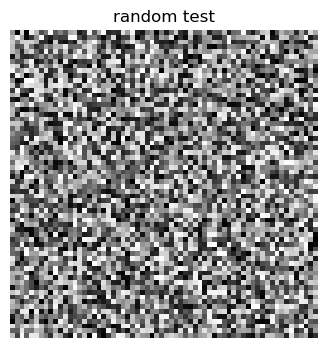

In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
plt.imshow(np.random.rand(64,64), cmap="gray")
plt.title("random test")
plt.axis("off")
plt.show()
